In [ ]:
!pip install pyspark
!pip install -U -q PyDrive
!apt install openjdk-8-jdk-headless -qq
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"

The following additional packages will be installed:
  libxtst6 openjdk-8-jre-headless
Suggested packages:
  openjdk-8-demo openjdk-8-source libnss-mdns fonts-dejavu-extra fonts-nanum fonts-ipafont-gothic
  fonts-ipafont-mincho fonts-wqy-microhei fonts-wqy-zenhei fonts-indic
The following NEW packages will be installed:
  libxtst6 openjdk-8-jdk-headless openjdk-8-jre-headless
0 upgraded, 3 newly installed, 0 to remove and 49 not upgraded.
Need to get 39.7 MB of archives.
After this operation, 144 MB of additional disk space will be used.
Selecting previously unselected package libxtst6:amd64.
(Reading database ... 123629 files and directories currently installed.)
Preparing to unpack .../libxtst6_2%3a1.2.3-1build4_amd64.deb ...
Unpacking libxtst6:amd64 (2:1.2.3-1build4) ...
Selecting previously unselected package openjdk-8-jre-headless:amd64.
Preparing to unpack .../openjdk-8-jre-headless_8u432-ga~us1-0ubuntu2~22.04_amd64.deb ...
Unpacking openjdk-8-jre-headless:amd64 (8u432-ga~us1-0ub

In [ ]:
from pyspark import SparkContext

In [ ]:
sc = SparkContext('local', 'My App')
sc

<SparkContext master=local appName=My App>

Load the JSON file into a DataFrame

In [ ]:
from pyspark.sql import SparkSession

# Initialize Spark session
spark = SparkSession.builder.master("local").appName("Movies Analysis").getOrCreate()



In [ ]:
from google.colab import files

# Upload the JSON file
uploaded = files.upload()


Saving movies.json to movies.json


In [ ]:
# Read the uploaded file
df = spark.read.json('movies.json')
df.show(5)

+--------------------+------------------+--------------------+---------+--------------------+--------------------+--------------------+--------------------+---------+--------------------+----------+------------------+--------------------+--------------------+-------+------------------+-------+--------------------+--------------------+-----+--------------------+--------------------+
|                 _id|            awards|                cast|countries|           directors|            fullplot|              genres|                imdb|languages|         lastupdated|metacritic|num_mflix_comments|                plot|              poster|  rated|          released|runtime|               title|            tomatoes| type|             writers|                year|
+--------------------+------------------+--------------------+---------+--------------------+--------------------+--------------------+--------------------+---------+--------------------+----------+------------------+-------------

1. Show the total number of movies in each genre with:



(a) Using the DataFrame API:

In [ ]:
from pyspark.sql.functions import explode

# Explode the genres list into multiple rows, then group and count
df_exploded = df.withColumn("genre", explode(df.genres))
df_genre_count = df_exploded.filter(df_exploded.genre.isNotNull()).groupBy("genre").count().orderBy("count", ascending=False)
df_genre_count.show()


+-----------+-----+
|      genre|count|
+-----------+-----+
|      Drama|13789|
|     Comedy| 7024|
|    Romance| 3665|
|      Crime| 2678|
|   Thriller| 2658|
|     Action| 2539|
|Documentary| 2129|
|  Adventure| 2045|
|     Horror| 1703|
|  Biography| 1404|
|     Family| 1311|
|    Mystery| 1259|
|    Fantasy| 1153|
|     Sci-Fi| 1034|
|    History|  999|
|  Animation|  971|
|      Music|  840|
|        War|  794|
|    Musical|  487|
|      Short|  478|
+-----------+-----+
only showing top 20 rows



(b) Using Spark SQL:

In [ ]:
# Register the DataFrame as a temporary SQL table
df.createOrReplaceTempView("movies")

# Use SQL to count movies by genre
result_sql = spark.sql("""
    SELECT genre, COUNT(*) as count
    FROM (SELECT explode(genres) as genre FROM movies)
    GROUP BY genre
    ORDER BY count DESC
""")
result_sql.show()


+-----------+-----+
|      genre|count|
+-----------+-----+
|      Drama|13789|
|     Comedy| 7024|
|    Romance| 3665|
|      Crime| 2678|
|   Thriller| 2658|
|     Action| 2539|
|Documentary| 2129|
|  Adventure| 2045|
|     Horror| 1703|
|  Biography| 1404|
|     Family| 1311|
|    Mystery| 1259|
|    Fantasy| 1153|
|     Sci-Fi| 1034|
|    History|  999|
|  Animation|  971|
|      Music|  840|
|        War|  794|
|    Musical|  487|
|      Short|  478|
+-----------+-----+
only showing top 20 rows



(c) Using RDD Operations:

In [ ]:
# Convert the DataFrame to an RDD and perform the count operation
rdd_genres = df.rdd.flatMap(lambda x: x['genres'] if x['genres'] is not None else [])
rdd_genre_count = rdd_genres.map(lambda genre: (genre, 1)) \
                            .reduceByKey(lambda x, y: x + y) \
                            .collect()
rdd_genre_count_sorted = sorted(rdd_genre_count, key=lambda x: x[1], reverse=True)
print(rdd_genre_count_sorted)

[('Drama', 13789), ('Comedy', 7024), ('Romance', 3665), ('Crime', 2678), ('Thriller', 2658), ('Action', 2539), ('Documentary', 2129), ('Adventure', 2045), ('Horror', 1703), ('Biography', 1404), ('Family', 1311), ('Mystery', 1259), ('Fantasy', 1153), ('Sci-Fi', 1034), ('History', 999), ('Animation', 971), ('Music', 840), ('War', 794), ('Musical', 487), ('Short', 478), ('Sport', 390), ('Western', 274), ('Film-Noir', 105), ('News', 51), ('Talk-Show', 1)]


Identify the most effiecient method

The DataFrame API is the most efficient method because it offers high-level operations with minimal code.
and it has better performance compared to RDD operations.

2. Find the directors who directed the highest number of movies

In [ ]:
df_exploded_directors = df.withColumn("director", explode(df.directors))
df_director_count = df_exploded_directors.groupBy("director").count().orderBy("count", ascending=False)
df_director_count.show(5)


+-------------+-----+
|     director|count|
+-------------+-----+
|  Woody Allen|   40|
|    John Ford|   35|
|Takashi Miike|   34|
|  John Huston|   34|
|Werner Herzog|   33|
+-------------+-----+
only showing top 5 rows



3. Determine the genres with the highest average IMDb rating:

In [ ]:
from pyspark.sql.functions import avg, col

df_genre_rating = df_exploded.groupBy("genre").agg(
    avg(col("imdb.rating.$numberDouble").cast("float")).alias("avg_rating")  #
).orderBy("avg_rating", ascending=False)

# Show the result
df_genre_rating.show()


+-----------+------------------+
|      genre|        avg_rating|
+-----------+------------------+
|  Film-Noir| 7.504123756565998|
|Documentary| 7.365563614908394|
|      Short| 7.355841134753183|
|       News|7.2448979494523025|
|    History| 7.207995506825748|
|        War|  7.19791667163372|
|  Biography| 7.099841529707145|
|      Music|6.9219736896063155|
|  Animation| 6.911251444493589|
|    Western| 6.870040503590696|
|      Drama|6.8276319017296245|
|      Sport| 6.785633815174371|
|      Crime| 6.725276076476755|
|    Musical| 6.701627904869789|
|    Romance| 6.688168761162392|
|    Mystery| 6.568374560073071|
|  Adventure| 6.522155037943382|
|     Comedy|6.4750673252751065|
|    Fantasy| 6.412900104670705|
|     Action| 6.367886715880666|
+-----------+------------------+
only showing top 20 rows



4. Find the month with the most movie releases based on the released date.

In [ ]:
from pyspark.sql.functions import col, month, to_date, from_unixtime

df_with_date = df.withColumn("released_date", from_unixtime(col("released.$date.$numberLong").cast("long") / 1000))
df_with_month = df_with_date.withColumn("month", month(col("released_date")))
df_month_count = df_with_month.groupBy("month").count().orderBy("count", ascending=False)
df_month_count.show(1)

+-----+-----+
|month|count|
+-----+-----+
|   10| 2522|
+-----+-----+
only showing top 1 row



5. Identify the top 5 movies with the longest runtime in each genre.

In [ ]:
from pyspark.sql.window import Window
window_spec = Window.partitionBy("genre").orderBy(col("runtime.$numberInt").cast("int").desc())
df.withColumn("genre", explode(col("genres"))).withColumn("runtime_int", col("runtime.$numberInt").cast("int")).filter(col("runtime_int").isNotNull()).withColumn("rank", row_number().over(window_spec)).filter(col("rank") <= 5).select("genre", "title", "runtime_int", "rank").orderBy("genre", "rank").show()

+---------+--------------------+-----------+----+
|    genre|               title|runtime_int|rank|
+---------+--------------------+-----------+----+
|   Action|          Centennial|       1256|   1|
|   Action|    Band of Brothers|        705|   2|
|   Action|           The Bible|        600|   3|
|   Action|        Les vampires|        399|   4|
|   Action|  Gangs of Wasseypur|        320|   5|
|Adventure|          Centennial|       1256|   1|
|Adventure|       Into the West|        552|   2|
|Adventure|    The 10th Kingdom|        417|   3|
|Adventure|The Count of Mont...|        400|   4|
|Adventure|        Les vampires|        399|   5|
|Animation|Walking with Preh...|        180|   1|
|Animation|                FLCL|        151|   2|
|Animation|Summer Days with Coo|        138|   3|
|Animation|The Tale of The P...|        137|   4|
|Animation|   Consuming Spirits|        136|   5|
|Biography|          John Adams|        501|   1|
|Biography|          John Adams|        501|   2|


6. Find the top 10 actors who appeared in the most movies. For each actor, list the number of movies and their average IMDb rating.

In [ ]:
from pyspark.sql.functions import explode, col, count, avg # Import count and avg
df.withColumn("actor", explode(col("cast"))).withColumn("imdb_rating", col("imdb.rating.$numberDouble").cast("double")).filter(col("actor").isNotNull()).groupBy("actor").agg(count("*").alias("movieCount"),avg("imdb_rating").alias("avgRating")).orderBy(col("movieCount").desc(), col("avgRating").desc()).limit(10).show()

+--------------------+----------+------------------+
|               actor|movieCount|         avgRating|
+--------------------+----------+------------------+
|    Gèrard Depardieu|        68| 6.659375000000002|
|      Robert De Niro|        60| 6.958490566037736|
|       Michael Caine|        53| 6.604347826086956|
|Marcello Mastroianni|        50|7.1688888888888895|
|       Max von Sydow|        49|              6.94|
|        Bruce Willis|        49| 6.446808510638298|
|      Morgan Freeman|        48| 7.172727272727273|
|   Samuel L. Jackson|        48| 6.390476190476191|
| Christopher Plummer|        47| 7.017948717948719|
|        Gene Hackman|        46| 6.757142857142859|
+--------------------+----------+------------------+



7. Plot a bar chart with the number of movies released each year.

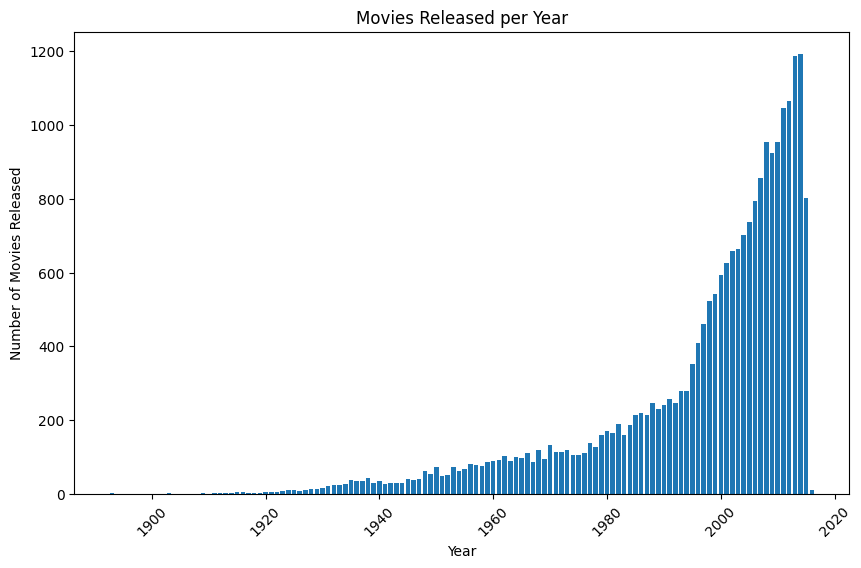

In [ ]:
from pyspark.sql.functions import col, year, from_unixtime

df_with_year = df.withColumn(
    "year",
    year(from_unixtime(col("released.$date.$numberLong").cast("long") / 1000))
)
df_year_count = df_with_year.groupBy("year").count().orderBy("year")

# Convert to Pandas DataFrame for plotting
df_pandas = df_year_count.toPandas()

import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(10, 6))
plt.bar(df_pandas['year'], df_pandas['count'])
plt.xlabel('Year')
plt.ylabel('Number of Movies Released')
plt.title('Movies Released per Year')
plt.xticks(rotation=45)
plt.show()